### Problem Statement: The objective of this project is to develop a Machine Learning classification model that predicts whether a patient is diabetic based on health-related attributes such as glucose level, blood pressure, BMI, insulin level, age, and pregnancy history. The model aims to assist healthcare professionals in identifying high-risk patients early, enabling timely treatment and improved patient outcomes.

### Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.metrics import confusion_matrix,classification_report
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv(r"C:\Users\dssas\OneDrive\Desktop\DS\Assignments\Logistic Regression Assignment\diabetes (1).csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### Understanding the dataset

In [ ]:
df.shape

(768, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Exploratory Data Analysis (EDA)

In [ ]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

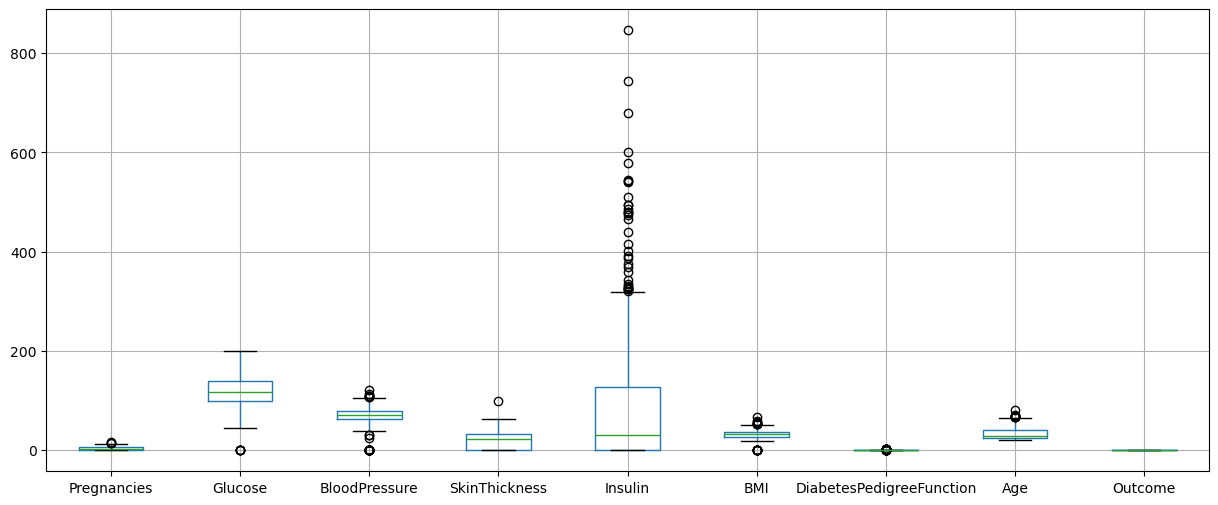

In [ ]:
plt.figure(figsize=(15,6))
df.boxplot()
plt.show()

### Correlation

<Axes: >

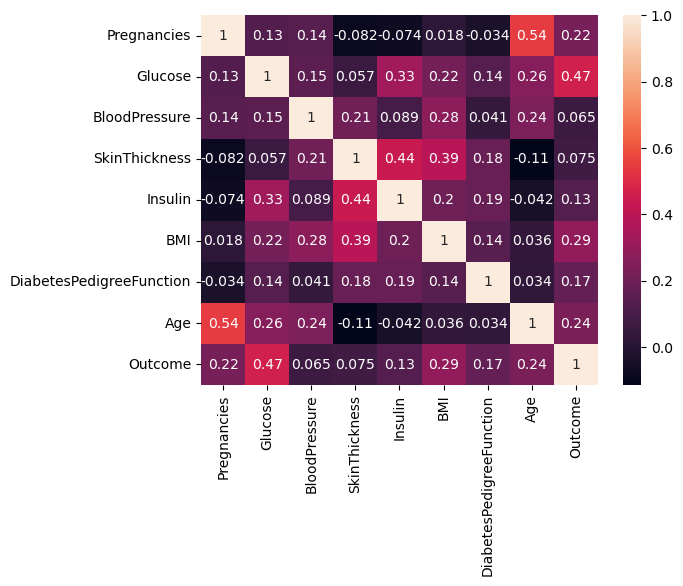

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

### Check Multicolinearity

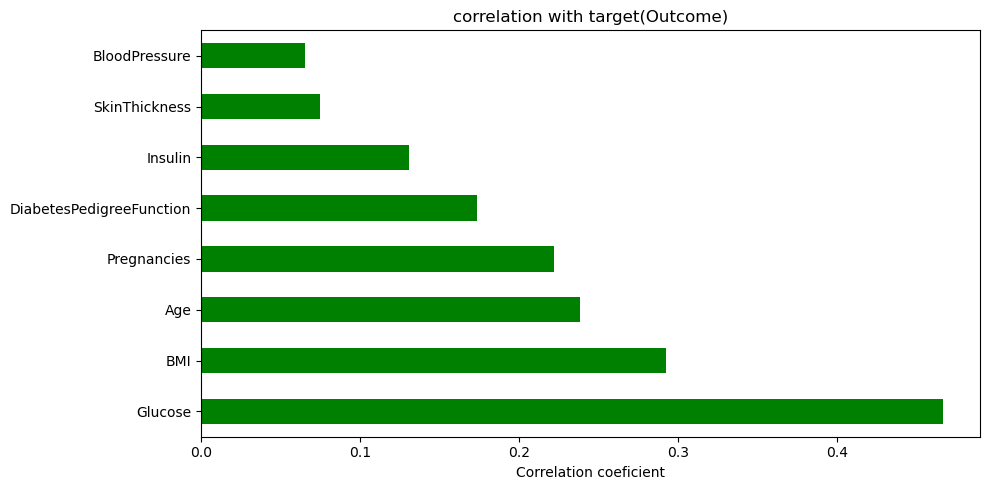

In [ ]:
numeric_df=df.select_dtypes(include=[int, float])
target_corr= numeric_df.corr()['Outcome'].drop('Outcome').sort_values(key=abs, ascending=False)

plt.figure(figsize=(10,5))
target_corr.plot(kind='barh', color=['green' if v >0 else 'red' for v in target_corr])
plt.title('correlation with target(Outcome)')
plt.xlabel('Correlation coeficient')
plt.tight_layout()
plt.show()

### Define X and Y

In [ ]:
x=df.iloc[:,:-1]
y=df['Outcome']

### Split Data for  training as well as  testing


In [ ]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2, random_state=0)

### Model Training

In [ ]:
lr=LogisticRegression()
lr.fit(xtrain,ytrain)

LogisticRegression()

In [ ]:
lr.coef_

array([[ 0.0908904 ,  0.03421397, -0.01395748,  0.00288146, -0.00144199,
         0.08916714,  0.82346343,  0.01567841]])

In [ ]:
lr.intercept_

array([-8.02180595])

### Prediction

In [ ]:
ypred=lr.predict(xtest)
ypred

array([1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0])

### Evaluate the model

In [ ]:
confusion_matrix(ytest, ypred)

array([[98,  9],
       [18, 29]])

<Axes: >

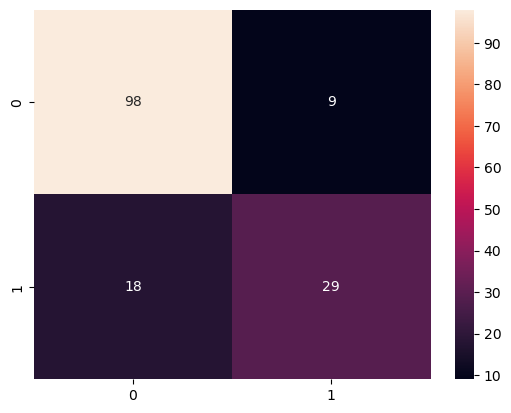

In [ ]:
sns.heatmap(confusion_matrix(ytest,ypred),annot=True, fmt='g')

In [ ]:
print(classification_report(ytest, ypred))

              precision    recall  f1-score   support

           0       0.84      0.92      0.88       107
           1       0.76      0.62      0.68        47

    accuracy                           0.82       154
   macro avg       0.80      0.77      0.78       154
weighted avg       0.82      0.82      0.82       154



In [ ]:
print(f'Training Accurary: {lr.score(xtrain,ytrain)}')
print(f'Testing Accuray: {lr.score(xtest,ytest)}')

Training Accurary: 0.7719869706840391
Testing Accuray: 0.8246753246753247


### Conclusion: The Logistic Regression model provides a reliable baseline for diabetes prediction with good overall accuracy.